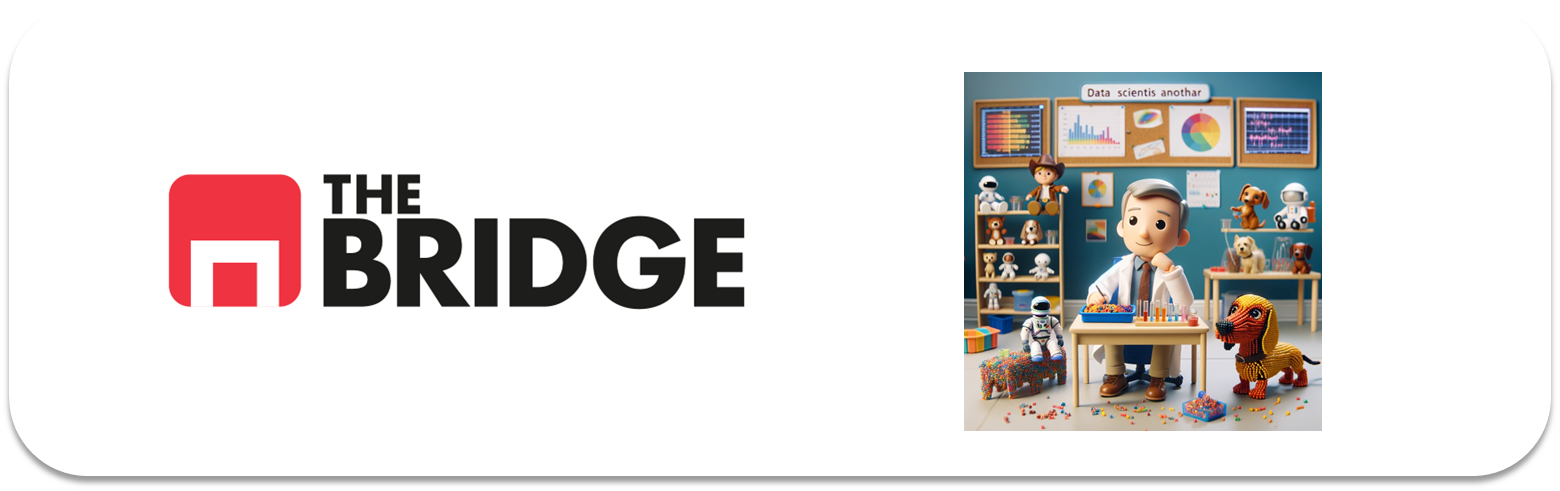

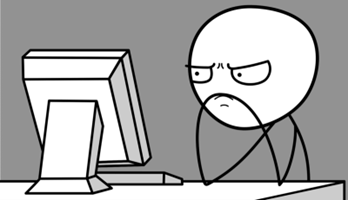

Para ejercitarte y afianzar lo aprendido sobre dispersión, distribución y outliers, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Ejercicio 1

Carga en un dataframe los datos contenidos en la ruta "./data/car_crashes.csv", muestra un parte de su contenido y la info general del mismo

In [3]:
df = pd.read_csv("./data/car_crashes.csv", sep = "|")

In [6]:
df

,Unnamed: 0,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51 non-null     int64  
 1   total           51 non-null     float64
 2   speeding        51 non-null     float64
 3   alcohol         51 non-null     float64
 4   not_distracted  51 non-null     float64
 5   no_previous     51 non-null     float64
 6   ins_premium     51 non-null     float64
 7   ins_losses      51 non-null     float64
 8   abbrev          51 non-null     object 
dtypes: float64(7), int64(1), object(1)
memory usage: 3.7+ KB


### Ejercicio 2

Haz una pequeña descripción de lo que crees que puede representar cada una de las variables y de que puede representar el dataset. Aunque para algunas se proporciona aquí:

* "total" - Número de accidentes fatales por colisión de vehículos por mil millones de millas
* "ins_premiums" - Prima media de Seguros de Automóviles ($)
* "ins_losses" - Pérdidas incurridas por las compañías de seguros por colisiones por conductor asegurado ($)

**ACLARACION IMPORTANTE**: El resto de columnas están dadas en las mismas unidades que total (numero de accidentes fatales por mil millones de millas)

* "speeding" - (exceso de velocidad del coche accidentado ¿ por mil millones de millas?) o cuantos coches han tenido el accidente por exceso de velocidad.  
* "alcohol" - ¿número de personas con alto contenido de alcohol en sangre? o ¿ índices de alcoholemia? o en cuantos accidentes está involucrado el alcohol.   
* "not_distracted" - número de accidentes sin distracciones.  
* "no_previous" - cuantos de esos accidentes no habián tenido ninguno previo.  
* "abbrev" - abreviatura del estado de USA al que se refieren los datos.

El dataset representa accidentes de automoviles en carretera en 51 estados de USA

In [12]:
df["abbrev"].nunique()

51

### Ejercicio 3

Vamos a analizar las medidas de tendencia central (media, mediana), las de posición (los cuartiles) y los rangos de las variables numéricas del dataset. Muestra esos valores para todas las variables numéricas del dataset.  

**IMPORTANTE**:
*Al ser los valores porcentajes, tenemos que convertirlos a valores absolutos (multiplicar los valores de las columnas de cada fila por el total de esa fila, excepto total) si queremos poder contabilizar medias reales entre todos los estados*  


In [4]:
df_copia = df[["speeding", "alcohol", "not_distracted", "no_previous"]].copy()    

In [5]:
df_copia

,speeding,alcohol,not_distracted,no_previous
0,7.332,5.640,18.048,15.040
1,7.421,4.525,16.290,17.014
2,6.510,5.208,15.624,17.856
3,4.032,5.824,21.056,21.280
4,4.200,3.360,10.920,10.680
5,5.032,3.808,10.744,12.920
6,4.968,3.888,9.396,8.856
7,6.156,4.860,14.094,16.038
8,2.006,1.593,5.900,5.900
9,3.759,5.191,16.468,16.826


In [6]:
for i in range(len(df_copia)):
    df_copia.loc[i] = df_copia.loc[i] * df_copia.loc[i].sum()


In [22]:
df_copia

,speeding,alcohol,not_distracted,no_previous
0,337.711920,259.778400,831.290880,692.742400
1,335.800250,204.756250,737.122500,769.883500
2,294.238980,235.391184,706.173552,807.055488
3,210.438144,303.966208,1098.954752,1110.645760
4,122.472000,97.977600,318.427200,311.428800
5,163.560128,123.775232,349.222976,419.951680
6,134.672544,105.395904,254.706768,240.068448
7,253.307088,199.979280,579.939912,659.931624
8,30.890394,24.530607,90.854100,90.854100
9,158.795196,219.288604,695.674192,710.797544


Vamos a analizar las medidas de tendencia central (media, mediana), las de posición (los cuartiles) y los rangos de las variables numéricas del dataset. Muestra esos valores para todas las variables numéricas del dataset.

In [9]:
print(df_copia.describe())

         speeding     alcohol  not_distracted  no_previous
count   51.000000   51.000000       51.000000    51.000000
mean   203.034321  198.897738      551.707603   560.257005
std    127.878315  126.320844      323.613183   287.980581
min     30.890394   24.530607       48.322560    90.854100
25%    112.769964  115.886057      290.163942   316.090876
50%    158.795196  164.256822      493.461720   525.073536
75%    291.792274  236.377512      703.151400   707.096272
max    555.673088  599.770500     1413.744750  1228.101500


In [10]:
df_copia.describe().loc["max"] - df_copia.describe().loc["min"]

speeding           524.782694
alcohol            575.239893
not_distracted    1365.422190
no_previous       1137.247400
dtype: float64

### Ejercicio 4

¿Qué puedes decir de la variable abbrev?¿Qué crees que podríamos hacer con ella?¿Le cambiarías el nombre?

Le cambiaría el nombre por "estado" y la convertiría en el índice.

Nota: Para los siguientes ejercicios te convendrá hacerte una función que obtenga el CV (Coeficiente de variación), y guardárla para el futuro

In [11]:
def calculo_cv(df):
    df_cv = df.describe().loc[["std","mean"]].T
    df_cv["CV"]= (df_cv["std"] / df_cv["mean"]) *100
    return df_cv


### Ejercicio 5

Analiza `speeding` usando los valores obtenidos anteriormente, obten su CV (coeficiente de variación), su diagrama de caja y su histograma (muéstralos). ¿Qué puedes decir de la misma? [Nota: puedes utilizar la función `plot_combined_graphs`, del módulo `bootcampviztools`, que admite un dataframe, una lista de columnas, el ancho de los bigotes y el número de bines y muestra el histograma y el diagrama de caja]

In [12]:
calculo_cv(df_copia["speeding"])

std     127.878315
mean    203.034321
CV       62.983595
Name: speeding, dtype: float64

In [13]:
from bootcampviztools import plot_combined_graphs

(2,)


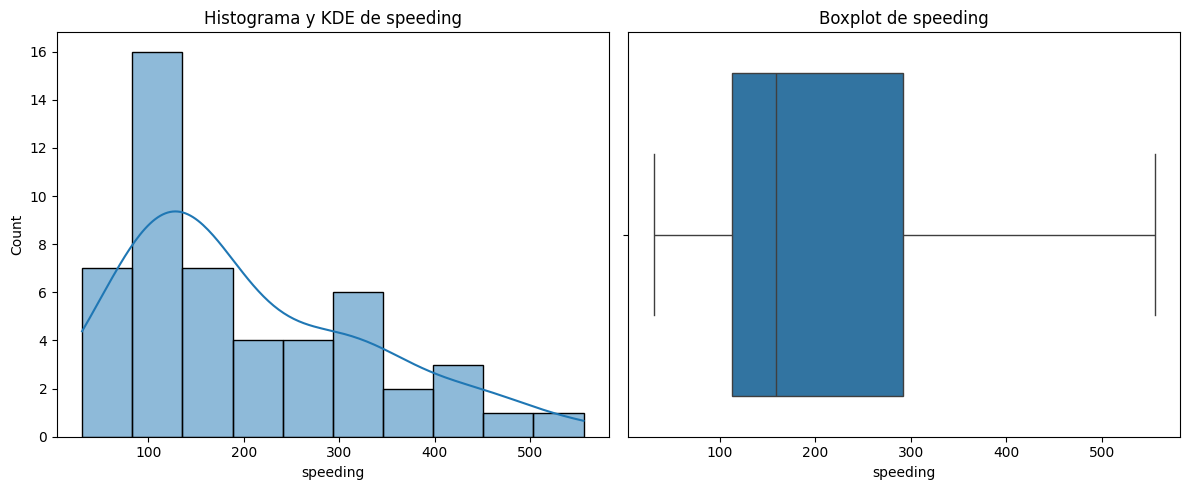

In [26]:
plot_combined_graphs(df_copia, ["speeding"], whisker_width=3.0,bins=10)

La mayoría de los accidentes no tienen que ver con excesos de velocidad muy altos. La mayoría está entre el cuartil 25% y el cuartil del 75%, entre los valores 112 y 291. Con un pico importante alrededor del valor 100. ¿A que se debe esa concentración? 
Aunque son mayor el número de excesos de velocidad en el tramo de valores de 150 a 300, tiene una larga cola hasta el valor máximo 555.

### Ejercicio 6

Analiza `alcohol` usando los valores obtenidos anteriormente, obten su CV (coeficiente de variación), su diagrama de caja y su histograma (muéstralos). ¿Qué puedes decir de la misma? [Nota: puedes utilizar la función `plot_combined_graphs`, del módulo `bootcampviztools`, que admite un dataframe, una lista de columnas, el ancho de los bigotes y el número de bines y muestra el histograma y el diagrama de caja]

std     126.320844
mean    198.897738
CV       63.510448
Name: alcohol, dtype: float64
(2,)


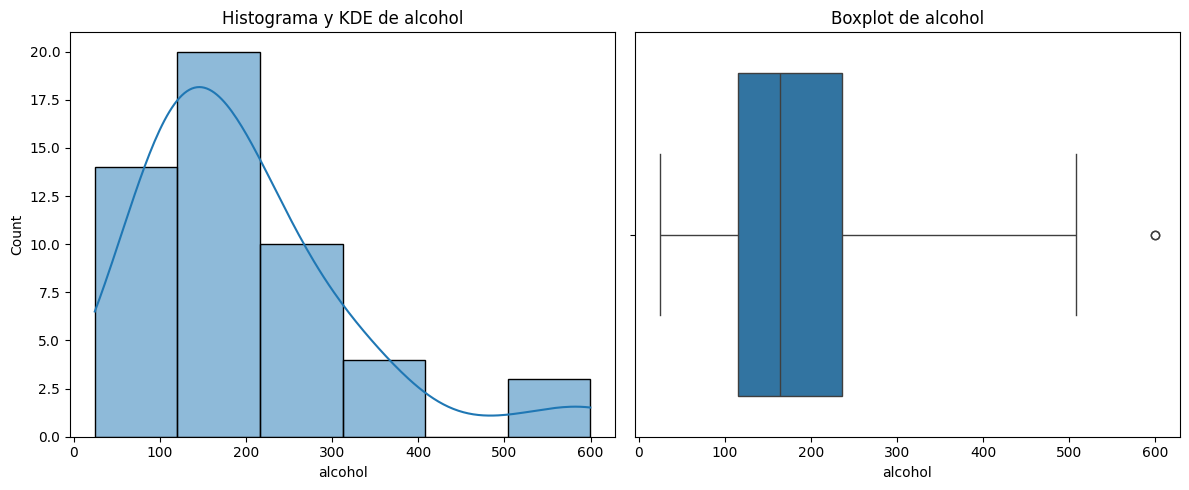

In [27]:
print(calculo_cv(df_copia["alcohol"]))

plot_combined_graphs(df_copia, ["alcohol"], whisker_width=3.0,bins=6)

El 75% de los accidentes no están causados por enormes consumos de alcohol, aunque hay algunos casos (outliers) que duplican la máxima de ese 75%. 

### Ejercicio 7

Analiza `not_distracted` usando los valores obtenidos anteriormente, obten su CV (coeficiente de variación), su diagrama de caja y su histograma (muéstralos). ¿Qué puedes decir de la misma? [Nota: puedes utilizar la función `plot_combined_graphs`, del módulo `bootcampviztools`, que admite un dataframe, una lista de columnas, el ancho de los bigotes y el número de bines y muestra el histograma y el diagrama de caja]

std     323.613183
mean    551.707603
CV       58.656647
Name: not_distracted, dtype: float64
(2,)


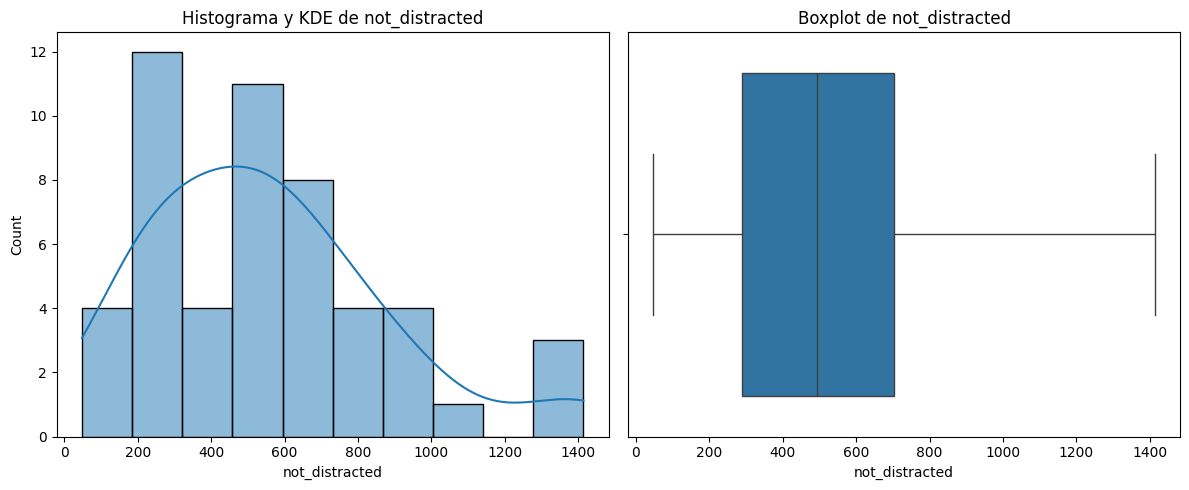

In [29]:
print(calculo_cv(df_copia["not_distracted"]))

plot_combined_graphs(df_copia, ["not_distracted"], whisker_width=3.0,bins=10)

Visto el histograma creo que la mayoría de accidentes de deben a distracciones. La mayoría del conteo se engloba en el tramo del mínimo al cuartil 75%.  
Hay una cantidad de accidentes, como una cuarta parte, que no se deben tanto a la distracción, ¿tendrán que ver con el exceso de velocidad o el alcohol? 

### Ejercicio 8

El diagrma de violín es un tipo de gráfico que no hemos usado pero que tu puedes usar para tu análisis. Combina elementos de diagrama de caja y de la estimación de la función de densidad. 

Ejecuta la siguiente celda y luego dibuja el boxplot y el histograma combinado con la función de densidad para ver qué te parece más interesante. Usa `plot_combined_graphs`)

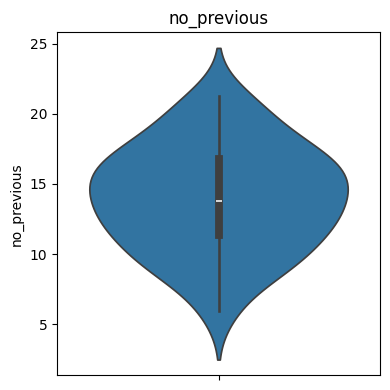

In [30]:
from bootcampviztools import mostrar_diagramas_violin

mostrar_diagramas_violin(df, ["no_previous"])

La figura presenta un plotbox interno con la mediana marcada con una línea gruesa y el rango intercuartílico dibujado en el centro, además de que la forma se lo da la función densidad estimada (replicada simétricamente):

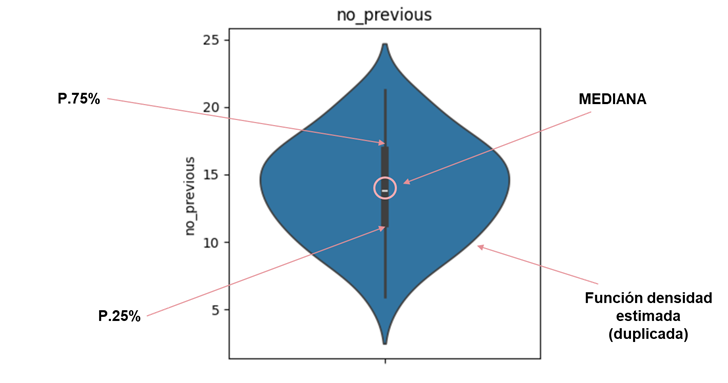

(2,)


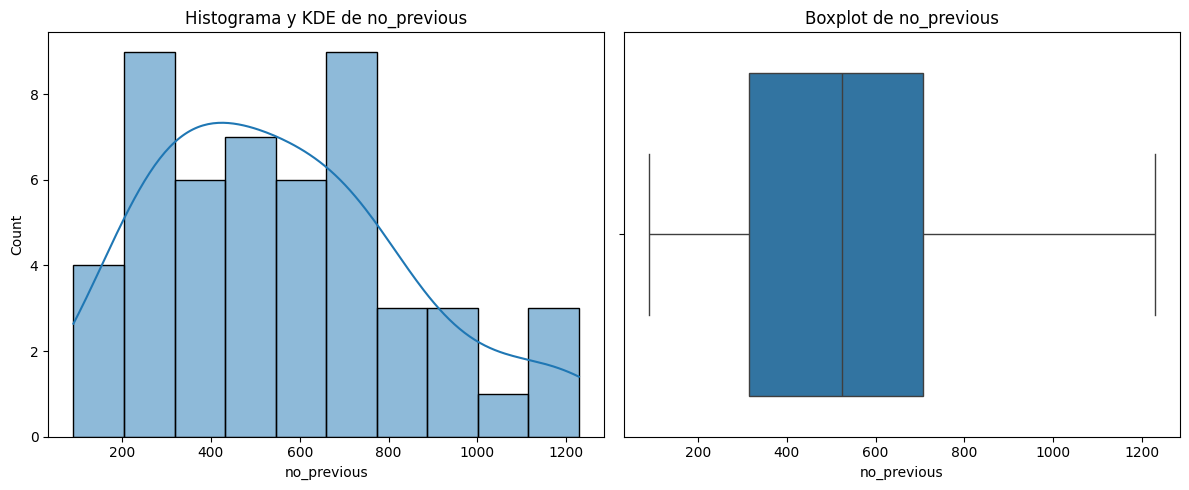

In [31]:
plot_combined_graphs(df_copia, ["no_previous"], whisker_width=3.0,bins=10)

### Ejercicio 9

Completa el análisis de "no_previous" con su CV y sus medidas de tendencia central. ¿Qué destacarías? (considera gráficas y medidas obtenidas en este apartado)

In [33]:
print(calculo_cv(df_copia["no_previous"]))

std     287.980581
mean    560.257005
CV       51.401514
Name: no_previous, dtype: float64


Que la mayoría ha tenido accidentes previos.

En general destacaría que los accidentes se deben a distracciones más que al exceso de velocidad y al alcohol, y que esa mayoría ya había tenido algún accidente anteriormente.

### Ejercicio 10

Carga el dataset de los seguros ("./data/Marketing-Customer-Analysis.csv") en un datafame y pinta la gráfica de caja y el histograma de "customer_lifetime_value"

In [34]:
df_ser = pd.read_csv("./data/Marketing-Customer-Analysis.csv")

In [35]:
print(df_ser["customer_lifetime_value"].describe())

count     9134.000000
mean      8004.940475
std       6870.967608
min       1898.007675
25%       3994.251794
50%       5780.182197
75%       8962.167041
max      83325.381190
Name: customer_lifetime_value, dtype: float64


### Ejercicio 11

Para "customer_lifetime_value", escoge un umbral para marcar como outliers los valores que lo superen. Divide el dataframe en dos usando ese valor.

In [45]:
df_ser_1 = df_ser[df_ser["customer_lifetime_value"] < 11000]
df_ser_umbral = df_ser[df_ser["customer_lifetime_value"] > 11000]

### Ejericicio 12

Compara los histogramas para "customer_lifetime_value" de cada dataframe. ¿Qué conclusiones sacas?

<Axes: >

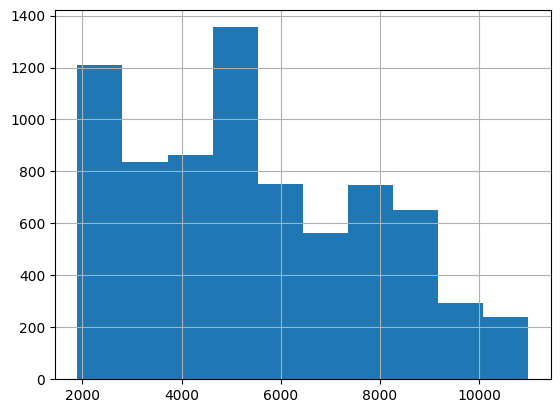

In [46]:
df_ser_1["customer_lifetime_value"].hist()

<Axes: >

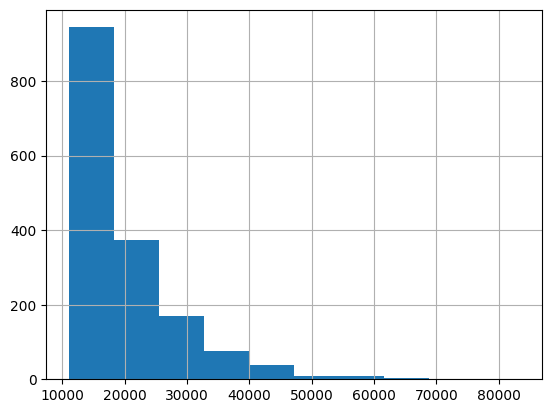

In [47]:
df_ser_umbral["customer_lifetime_value"].hist()

La empresa gana más en terminos absolutos con una mayor cantidad de clientes con menos valor a lo largo de su relación.